In [82]:
#import 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
#load data
df=pd.read_csv("loan_approval_data.csv")

In [3]:
df.head(10)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes
5,6.0,8265.0,4831.0,Salaried,53.0,Single,1.0,602.0,1.0,0.56,19522.0,2911.0,9798.0,36.0,Home,Semiurban,Graduate,Male,Unemployed,No
6,7.0,18850.0,2768.0,Salaried,58.0,Married,0.0,687.0,0.0,0.48,14635.0,8991.0,26143.0,24.0,Home,Rural,Graduate,Male,Private,No
7,8.0,6426.0,3186.0,Salaried,47.0,Married,2.0,636.0,4.0,NaN,671.0,11572.0,33747.0,84.0,Personal,Rural,Graduate,Female,NaN,No
8,9.0,16423.0,NaN,Salaried,54.0,Married,1.0,729.0,0.0,0.59,777.0,43066.0,34651.0,36.0,Home,Semiurban,Graduate,Male,Private,No
9,10.0,13363.0,2599.0,Contract,35.0,Single,3.0,726.0,1.0,NaN,3022.0,29693.0,22182.0,60.0,Personal,Rural,Graduate,Female,Government,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [5]:
df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


In [6]:
#hamdle missing values
categorical_cols=df.select_dtypes(include=["object"]).columns
numericla_cols=df.select_dtypes(include=["number"]).columns

In [7]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [8]:
numericla_cols

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [9]:
#fill missing values
#use the imputer to fill it
from sklearn.impute import SimpleImputer
num_imp=SimpleImputer(strategy="mean")
df[numericla_cols]=num_imp.fit_transform(df[numericla_cols])

In [10]:
df[numericla_cols].isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Age                   0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
dtype: int64

In [11]:
cat_imp=SimpleImputer(strategy="most_frequent")
df[categorical_cols]=cat_imp.fit_transform(df[categorical_cols])

In [12]:
df[categorical_cols].isnull().sum()

Employment_Status    0
Marital_Status       0
Loan_Purpose         0
Property_Area        0
Education_Level      0
Gender               0
Employer_Category    0
Loan_Approved        0
dtype: int64

In [13]:
df.head(10)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.000000,Salaried,51.0,Married,0.0,637.0,4.0,0.530000,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.000000,Salaried,46.0,Married,3.0,621.0,2.0,0.300000,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.000000,Salaried,25.0,Single,2.0,674.0,4.0,0.200000,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.000000,Salaried,40.0,Married,2.0,579.0,3.0,0.310000,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.000000,Self-employed,31.0,Single,2.0,721.0,1.0,0.290000,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
5,6.0,8265.0,4831.000000,Salaried,53.0,Single,1.0,602.0,1.0,0.560000,19522.0,2911.0,9798.0,36.0,Home,Semiurban,Graduate,Male,Unemployed,No
6,7.0,18850.0,2768.000000,Salaried,58.0,Married,0.0,687.0,0.0,0.480000,14635.0,8991.0,26143.0,24.0,Home,Rural,Graduate,Male,Private,No
7,8.0,6426.0,3186.000000,Salaried,47.0,Married,2.0,636.0,4.0,0.347263,671.0,11572.0,33747.0,84.0,Personal,Rural,Graduate,Female,Private,No
8,9.0,16423.0,5082.455789,Salaried,54.0,Married,1.0,729.0,0.0,0.590000,777.0,43066.0,34651.0,36.0,Home,Semiurban,Graduate,Male,Private,No
9,10.0,13363.0,2599.000000,Contract,35.0,Single,3.0,726.0,1.0,0.347263,3022.0,29693.0,22182.0,60.0,Personal,Rural,Graduate,Female,Government,Yes


In [14]:
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

In [15]:
#we sucssefully handle the missing values

Text(0.5, 1.0, 'Gender Ratio')

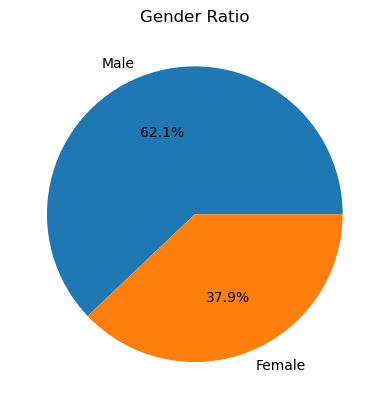

In [16]:
gen_count=df["Gender"].value_counts()
plt.pie(gen_count,labels=["Male","Female"],autopct="%1.1f%%")
plt.title("Gender Ratio")
#it means male applies large number of application for loan

Text(0.5, 1.0, 'approve or not')

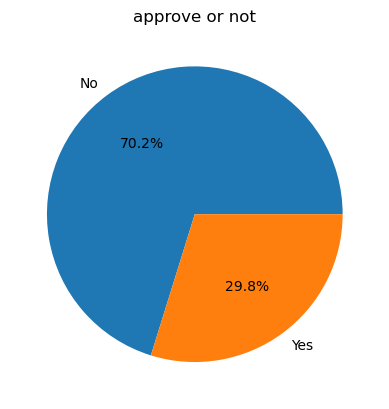

In [17]:
#approve or not
ap_count=df["Loan_Approved"].value_counts()
plt.pie(ap_count,labels=["No","Yes"],autopct="%1.1f%%")
plt.title("approve or not")
#it means that only 28% loan is approve

Text(0.5, 1.0, 'Education level of applicants')

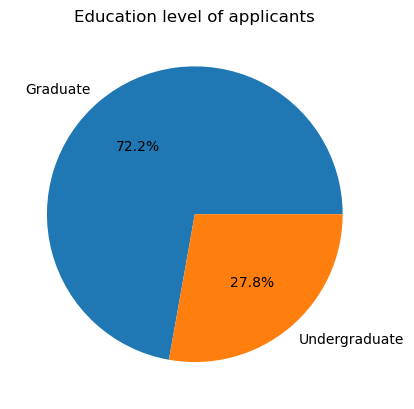

In [18]:
#Education level of applicants
edu_count=df["Education_Level"].value_counts()
plt.pie(edu_count,labels=["Graduate","Undergraduate"],autopct="%1.1f%%")
plt.title("Education level of applicants")
#it means that only 28% loan is approve

<Axes: xlabel='Applicant_Income', ylabel='Count'>

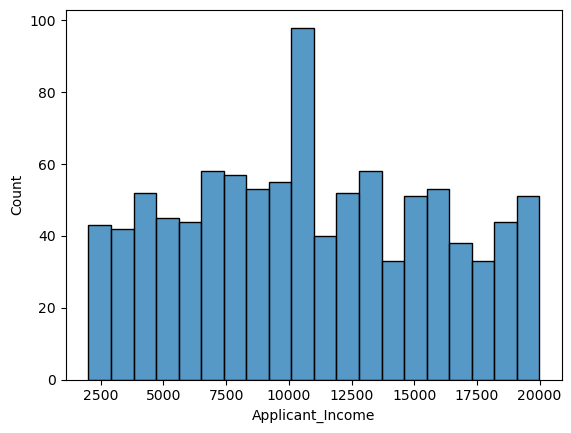

In [19]:
#anayle income
sns.histplot(
    data=df,
    x=df["Applicant_Income"],
    bins=20
)
#it means that Applicant incomes are large in 10000 to 11000

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

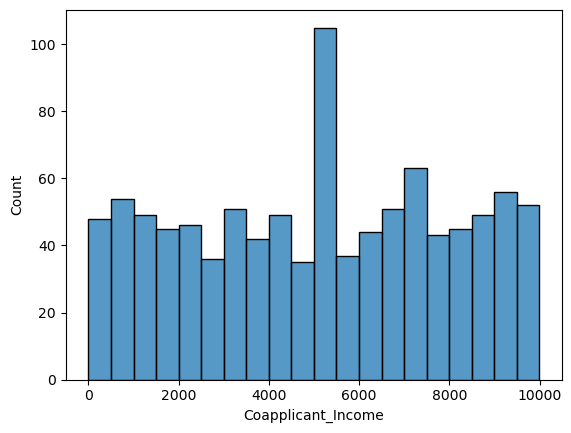

In [20]:
#anlyse the co-applicant income
sns.histplot(
    data=df,
    x=df["Coapplicant_Income"],
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

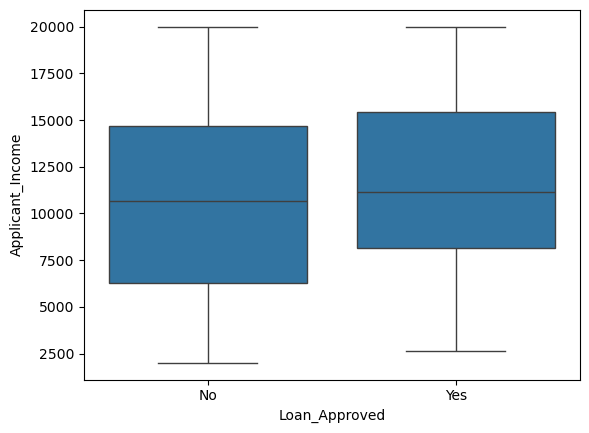

In [21]:
#outlier detection
sns.boxplot(
    data=df,
    y="Applicant_Income",
    x="Loan_Approved"
)

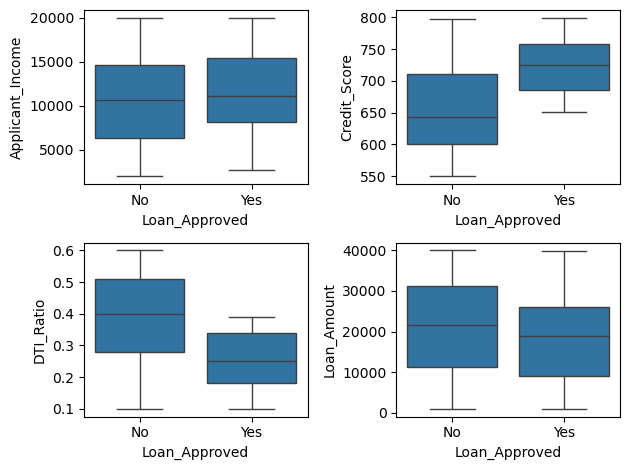

In [22]:
fig,axes=plt.subplots(2,2)

sns.boxplot(ax=axes[0,0],data=df,y="Applicant_Income",x="Loan_Approved")
sns.boxplot(ax=axes[0,1],data=df,y="Credit_Score",x="Loan_Approved")
sns.boxplot(ax=axes[1,0],data=df,y="DTI_Ratio",x="Loan_Approved")
sns.boxplot(ax=axes[1,1],data=df,y="Loan_Amount",x="Loan_Approved")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

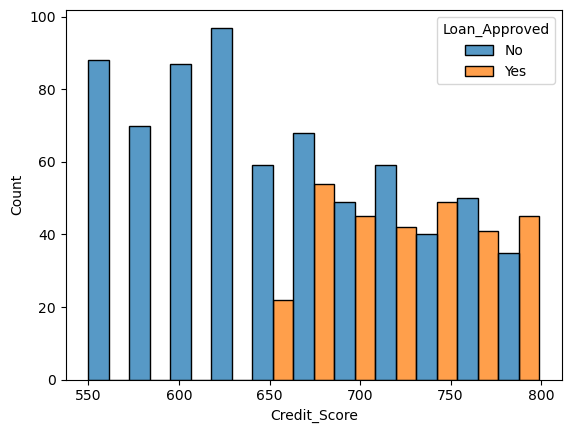

In [23]:
#anlyse the crdit score
sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    multiple="dodge"
)

In [24]:
#from above histogram we analyse that if credit score >=650 then probability of loan approvle is increases 

In [25]:
#remove aplicant id
df=df.drop(columns=["Applicant_ID"])

In [26]:
df

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.000000,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.000000,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.000000,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.000000,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.000000,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,Not Graduate,Male,Unemployed,No
996,3279.000000,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,15192.000000,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,9083.000000,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


In [27]:
#Encoding
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

In [28]:
#Label encoding for Loan_Approved,Education_Level
lb=LabelEncoder()
df["Loan_Approved"]=lb.fit_transform(df["Loan_Approved"])
df["Education_Level"]=lb.fit_transform(df["Education_Level"])

In [69]:
df["Loan_Approved"]

0      0
1      0
2      1
3      0
4      1
      ..
995    0
996    0
997    0
998    1
999    0
Name: Loan_Approved, Length: 1000, dtype: int64

In [30]:
#onehotEncoding for Employment_Status,Marital_Status,Loan_Purpose,Property_Area,Gender,Employer_Category

cols=["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]
ohe=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")

encoded=ohe.fit_transform(df[cols])

In [31]:
encoded

array([[1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.]], shape=(1000, 15))

In [32]:
ohe.get_feature_names_out(cols)

array(['Employment_Status_Salaried', 'Employment_Status_Self-employed',
       'Employment_Status_Unemployed', 'Marital_Status_Single',
       'Loan_Purpose_Car', 'Loan_Purpose_Education', 'Loan_Purpose_Home',
       'Loan_Purpose_Personal', 'Property_Area_Semiurban',
       'Property_Area_Urban', 'Gender_Male',
       'Employer_Category_Government', 'Employer_Category_MNC',
       'Employer_Category_Private', 'Employer_Category_Unemployed'],
      dtype=object)

In [33]:
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols),index=df.index)

In [34]:
encoded_df.head(10)

,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Marital_Status_Single,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
5,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
6,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
7,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
9,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [35]:
#append with original df
df=pd.concat([df.drop(columns=cols),encoded_df],axis=1)

In [36]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

In [38]:
#correlation heatmap
numericla_cols=df.select_dtypes(include="number")

In [39]:
corr_matrix=numericla_cols.corr()
corr_matrix

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
Applicant_Income,1.000000,0.007545,-0.023988,-0.026658,-0.009818,-0.010457,-0.009107,-0.028358,0.018789,-0.024143,...,0.032794,0.074209,-0.031234,0.004845,-0.036260,-0.020871,-0.025011,0.102589,-0.044639,-0.011995
Coapplicant_Income,0.007545,1.000000,0.014306,-0.026733,0.058423,0.012418,0.058078,-0.015047,0.009457,0.001596,...,0.028000,0.016022,0.059549,-0.010058,0.030045,-0.010148,-0.001146,0.037640,0.004312,-0.047929
Age,-0.023988,0.014306,1.000000,-0.018767,-0.004212,0.023330,0.007903,-0.000986,0.037382,0.013502,...,-0.006283,0.029865,0.037293,0.003100,-0.025661,0.048402,-0.066041,0.021232,-0.012960,0.072462
Dependents,-0.026658,-0.026733,-0.018767,1.000000,-0.007687,-0.026338,0.011498,-0.004981,0.023004,-0.017409,...,-0.044642,0.027343,-0.005785,-0.032278,0.024082,0.013706,-0.009250,-0.018757,0.030197,-0.054147
Credit_Score,-0.009818,0.058423,-0.004212,-0.007687,1.000000,-0.007130,0.002338,-0.065353,0.007865,0.001002,...,0.026013,-0.008658,0.015324,-0.006946,0.004445,-0.039739,-0.007076,0.066736,-0.000049,-0.046087
Existing_Loans,-0.010457,0.012418,0.023330,-0.026338,-0.007130,1.000000,0.047008,0.034435,-0.049916,-0.021035,...,-0.010035,0.001777,0.023212,-0.053971,0.035629,-0.038762,-0.009642,0.030520,-0.019306,0.045391
DTI_Ratio,-0.009107,0.058078,0.007903,0.011498,0.002338,0.047008,1.000000,0.004663,-0.009622,0.075784,...,0.040432,-0.014125,-0.036648,0.044898,-0.006156,0.009624,-0.007214,0.002090,-0.003506,0.026018
Savings,-0.028358,-0.015047,-0.000986,-0.004981,-0.065353,0.034435,0.004663,1.000000,0.015481,-0.012208,...,0.032558,-0.012217,-0.028948,0.005438,0.016833,-0.006667,-0.011683,0.004381,-0.030208,0.027178
Collateral_Value,0.018789,0.009457,0.037382,0.023004,0.007865,-0.049916,-0.009622,0.015481,1.000000,0.002660,...,0.040406,-0.050975,-0.007120,0.020061,0.007975,0.000897,0.035760,-0.013464,-0.014480,-0.009655
Loan_Amount,-0.024143,0.001596,0.013502,-0.017409,0.001002,-0.021035,0.075784,-0.012208,0.002660,1.000000,...,-0.006119,-0.000930,0.032498,0.040206,-0.050076,0.103456,0.013108,-0.025975,0.013923,-0.026566


In [40]:
#correalation with output values
numericla_cols.corr()["Loan_Approved"].sort_values(ascending=False)


Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

<Axes: >

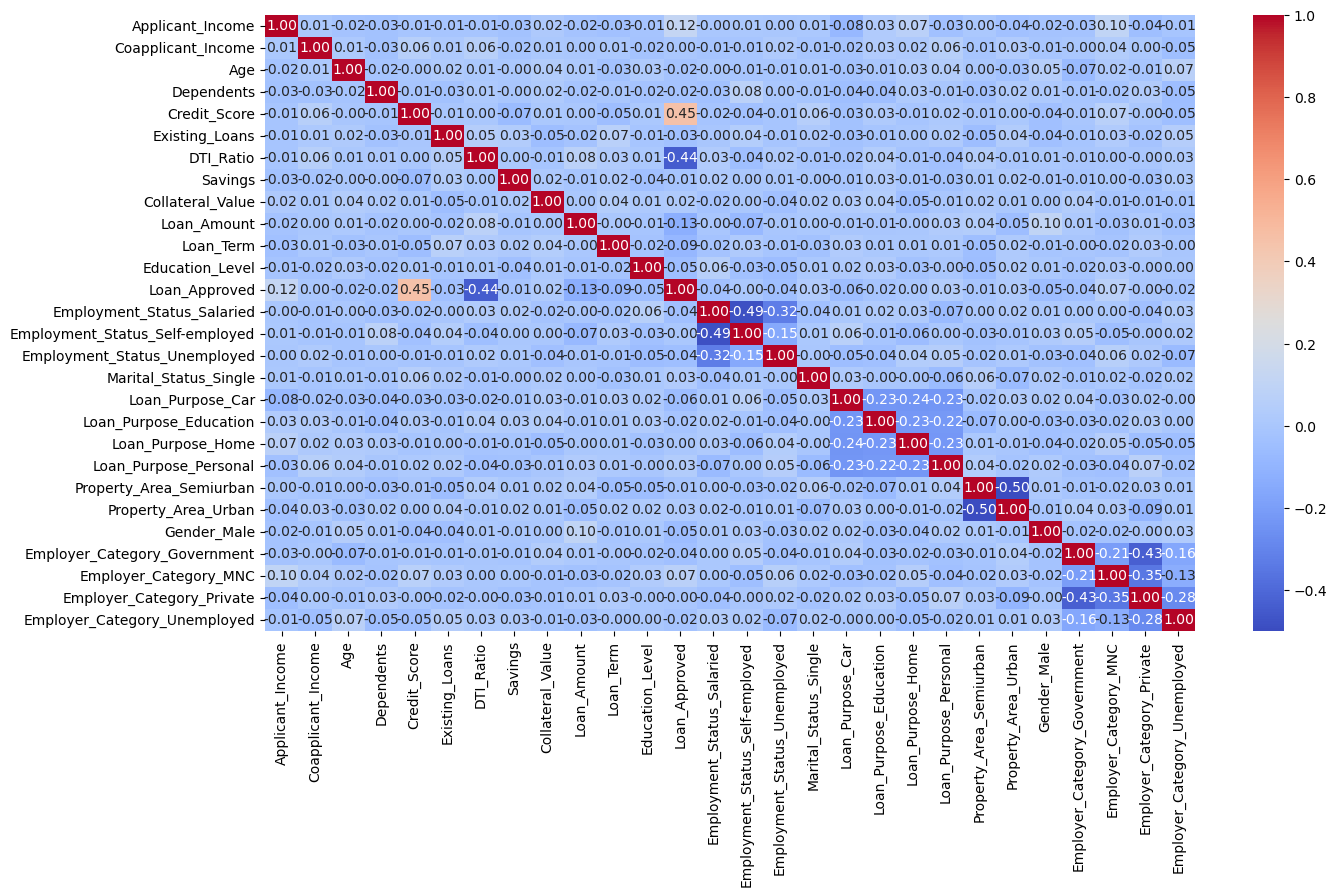

In [41]:
#correlation heatmap
plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
#this map is in light blue color
#so the give data is not work well with linear models


In [42]:
#train test split +feature scaling
X=df.drop("Loan_Approved",axis=1)
Y=df["Loan_Approved"]

In [62]:
X.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Existing_Loans,Savings,Collateral_Value,Loan_Amount,Loan_Term,Education_Level,...,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,DTI_Ratio_sq,Credit_Score_sq
0,17795.0,1387.0,51.0,0.0,4.0,19403.0,45638.0,16619.0,84.0,1,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.2809,405769.0
1,2860.0,2679.0,46.0,3.0,2.0,2580.0,49272.0,38687.0,48.0,0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0900,385641.0
2,7390.0,2106.0,25.0,2.0,4.0,13844.0,6908.0,27943.0,72.0,0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0400,454276.0
3,13964.0,8173.0,40.0,2.0,3.0,9553.0,10844.0,27819.0,60.0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0961,335241.0
4,13284.0,4223.0,31.0,2.0,1.0,9386.0,37629.0,12741.0,72.0,0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0841,519841.0


In [44]:
Y.head()

0    0
1    0
2    1
3    0
4    1
Name: Loan_Approved, dtype: int64

In [45]:
#train-tes-split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,train_size=0.2,random_state=42)

In [46]:
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
556,10702.0,8219.0,34.0,1.0,716.0,1.0,0.430000,14184.0,16052.000000,19130.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
957,12998.0,1179.0,33.0,3.0,767.0,0.0,0.550000,6044.0,18013.000000,39278.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
577,14775.0,575.0,49.0,3.0,682.0,0.0,0.120000,13747.0,10164.000000,11190.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
795,16060.0,8841.0,39.0,3.0,640.0,4.0,0.347263,19194.0,45530.000000,7553.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
85,8184.0,9130.0,57.0,1.0,626.0,2.0,0.110000,14893.0,24802.792632,16768.0,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [47]:
#feature scaling
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train_scale=scaler.fit_transform(X_train)
X_test_scale=scaler.transform(X_test)

In [48]:
X_train_scale

array([[-0.15637011,  1.1570858 , -0.56535255, ..., -0.46056619,
         1.0944415 , -0.2847474 ],
       [ 0.30380386, -1.38822064, -0.65612005, ..., -0.46056619,
         1.0944415 , -0.2847474 ],
       [ 0.65995767, -1.60659636,  0.79615998, ..., -0.46056619,
         1.0944415 , -0.2847474 ],
       ...,
       [-0.34055995,  0.39060147, -0.83765506, ..., -0.46056619,
         1.0944415 , -0.2847474 ],
       [ 1.00809451, -0.45433903,  1.15922999, ..., -0.46056619,
        -0.91370804, -0.2847474 ],
       [-1.85917413,  0.04242958, -0.02074754, ...,  2.17124059,
        -0.91370804, -0.2847474 ]], shape=(200, 27))

In [49]:
X_test_scale

array([[ 0.30881447,  0.59885382,  1.15922999, ..., -0.46056619,
         1.0944415 , -0.2847474 ],
       [ 0.88884211,  0.63934733,  0.16078746, ..., -0.46056619,
         1.0944415 , -0.2847474 ],
       [-0.78610295, -0.53821845,  1.06846248, ..., -0.46056619,
         1.0944415 , -0.2847474 ],
       ...,
       [-0.70112309, -1.32892657, -0.83765506, ..., -0.46056619,
         1.0944415 , -0.2847474 ],
       [-0.6225568 ,  0.9712495 ,  0.97769498, ..., -0.46056619,
        -0.91370804,  3.51188458],
       [-1.47636391, -1.73964647,  0.88692748, ..., -0.46056619,
        -0.91370804, -0.2847474 ]], shape=(800, 27))

In [50]:
#training and evaluation 1)Logistic regression 2)knn 3)naive bayes
#Logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,f1_score,recall_score

log_model=LogisticRegression()
log_model.fit(X_train_scale,Y_train)
y_predict=log_model.predict(X_test_scale)
print("Logistic Regression moddels:")
print("precision score: ",precision_score(Y_test,y_predict))
print("Recall score: ",recall_score(Y_test,y_predict))
print("F1 score: ",f1_score(Y_test,y_predict))
print("accuracy score: ",accuracy_score(Y_test,y_predict))
print("CM: ",confusion_matrix(Y_test,y_predict))


Logistic Regression moddels:
precision score:  0.7526881720430108
Recall score:  0.5714285714285714
F1 score:  0.6496519721577726
accuracy score:  0.81125
CM:  [[509  46]
 [105 140]]


In [51]:
#knn
from sklearn.neighbors import KNeighborsClassifier

knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scale,Y_train)

y_predict=knn_model.predict(X_test_scale)
print("KNN moddels:")
print("precision score: ",precision_score(Y_test,y_predict))
print("Recall score: ",recall_score(Y_test,y_predict))
print("F1 score: ",f1_score(Y_test,y_predict))
print("accuracy score: ",accuracy_score(Y_test,y_predict))
print("CM: ",confusion_matrix(Y_test,y_predict))

KNN moddels:
precision score:  0.7288135593220338
Recall score:  0.3510204081632653
F1 score:  0.4738292011019284
accuracy score:  0.76125
CM:  [[523  32]
 [159  86]]


In [52]:
#naie bayse
from sklearn.naive_bayes import GaussianNB

gnb_model=GaussianNB()
gnb_model.fit(X_train_scale,Y_train)

y_predict=gnb_model.predict(X_test_scale)
print("Naive Bayes moddels:")
print("precision score: ",precision_score(Y_test,y_predict))
print("Recall score: ",recall_score(Y_test,y_predict))
print("F1 score: ",f1_score(Y_test,y_predict))
print("accuracy score: ",accuracy_score(Y_test,y_predict))
print("CM: ",confusion_matrix(Y_test,y_predict))

Naive Bayes moddels:
precision score:  0.8424657534246576
Recall score:  0.5020408163265306
F1 score:  0.629156010230179
accuracy score:  0.81875
CM:  [[532  23]
 [122 123]]


In [53]:
#best model on the basis of accuracy is Naive Bayes

In [54]:
#feature engg
#add fetures
df["DTI_Ratio_sq"]=df["DTI_Ratio"]**2
df["Credit_Score_sq"]=df["Credit_Score"]**2

X=df.drop(columns=["Loan_Approved","DTI_Ratio","Credit_Score"])
Y=df["Loan_Approved"]

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,train_size=0.2,random_state=42)

X_train_scale=scaler.fit_transform(X_train)
X_test_scale=scaler.transform(X_test)

log_model.fit(X_train_scale,Y_train)
y_predict=log_model.predict(X_test_scale)
print("Logistic Regression moddels:")
print("precision score: ",precision_score(Y_test,y_predict))
print("Recall score: ",recall_score(Y_test,y_predict))
print("F1 score: ",f1_score(Y_test,y_predict))
print("accuracy score: ",accuracy_score(Y_test,y_predict))
print("CM: ",confusion_matrix(Y_test,y_predict))

Logistic Regression moddels:
precision score:  0.7727272727272727
Recall score:  0.6244897959183674
F1 score:  0.690744920993228
accuracy score:  0.82875
CM:  [[510  45]
 [ 92 153]]


In [55]:
#knn
knn_model.fit(X_train_scale,Y_train)

y_predict=knn_model.predict(X_test_scale)
print("KNN moddels:")
print("precision score: ",precision_score(Y_test,y_predict))
print("Recall score: ",recall_score(Y_test,y_predict))
print("F1 score: ",f1_score(Y_test,y_predict))
print("accuracy score: ",accuracy_score(Y_test,y_predict))
print("CM: ",confusion_matrix(Y_test,y_predict))

KNN moddels:
precision score:  0.7295081967213115
Recall score:  0.363265306122449
F1 score:  0.48501362397820164
accuracy score:  0.76375
CM:  [[522  33]
 [156  89]]


In [56]:
#naive bayse
gnb_model.fit(X_train_scale,Y_train)

y_predict=gnb_model.predict(X_test_scale)
print("Naive Bayes moddels:")
print("precision score: ",precision_score(Y_test,y_predict))
print("Recall score: ",recall_score(Y_test,y_predict))
print("F1 score: ",f1_score(Y_test,y_predict))
print("accuracy score: ",accuracy_score(Y_test,y_predict))
print("CM: ",confusion_matrix(Y_test,y_predict))

Naive Bayes moddels:
precision score:  0.8535031847133758
Recall score:  0.5469387755102041
F1 score:  0.6666666666666666
accuracy score:  0.8325
CM:  [[532  23]
 [111 134]]


In [63]:
#we chose logestic model for our prediction
#test
X.columns

Index(['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents',
       'Existing_Loans', 'Savings', 'Collateral_Value', 'Loan_Amount',
       'Loan_Term', 'Education_Level', 'Employment_Status_Salaried',
       'Employment_Status_Self-employed', 'Employment_Status_Unemployed',
       'Marital_Status_Single', 'Loan_Purpose_Car', 'Loan_Purpose_Education',
       'Loan_Purpose_Home', 'Loan_Purpose_Personal', 'Property_Area_Semiurban',
       'Property_Area_Urban', 'Gender_Male', 'Employer_Category_Government',
       'Employer_Category_MNC', 'Employer_Category_Private',
       'Employer_Category_Unemployed', 'DTI_Ratio_sq', 'Credit_Score_sq'],
      dtype='object')

In [71]:
import joblib

joblib.dump(lb, "label_encoder.pkl")
joblib.dump(ohe, "onehot_encoder.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(model, "logistic_regression_model.pkl")

['logistic_regression_model.pkl']

In [72]:

label_encoder = joblib.load("label_encoder.pkl")
onehot_encoder = joblib.load("onehot_encoder.pkl")
scaler = joblib.load("scaler.pkl")
model = joblib.load("logistic_regression_model.pkl")

In [104]:

# -----------------------------
# 1. New applicant
# -----------------------------
test = [[
    74444,
    338,
    "Salaried",
    34,
    "Married",
    2,
    738 * 738,
    0,
    0.21 * 0.21,
    18015,
    6333,
    30489,
    12,
    "Education",
    "Rural",
    "Not Graduate",
    "Male",
    "Business"
]]

test = pd.DataFrame(test, columns=[
    "Applicant_Income",
    "Coapplicant_Income",
    "Employment_Status",
    "Age",
    "Marital_Status",
    "Dependents",
    "Credit_Score_sq",
    "Existing_Loans",
    "DTI_Ratio_sq",
    "Savings",
    "Collateral_Value",
    "Loan_Amount",
    "Loan_Term",
    "Loan_Purpose",
    "Property_Area",
    "Education_Level",
    "Gender",
    "Employer_Category"
])


# -----------------------------
# 2. Label Encoding
# -----------------------------
test["Education_Level"] = label_encoder.transform(
    test["Education_Level"]
)


# -----------------------------
# 3. One-Hot Encoding
# -----------------------------
cols = [
    "Employment_Status",
    "Marital_Status",
    "Loan_Purpose",
    "Property_Area",
    "Gender",
    "Employer_Category"
]

encoded = onehot_encoder.transform(test[cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=onehot_encoder.get_feature_names_out(cols),
    index=test.index
)


# -----------------------------
# 4. Combine numerical + encoded columns
# -----------------------------
test = pd.concat(
    [test.drop(columns=cols), encoded_df],
    axis=1
)


# -----------------------------
# 5. Put columns in EXACT
#    training order
# -----------------------------
test = test[scaler.feature_names_in_]


# -----------------------------
# 6. Scale the test data
# -----------------------------
test_scaled = scaler.transform(test)


# -----------------------------
# 7. Prediction
# -----------------------------
prediction = model.predict(test_scaled)

print(prediction)

[1]


In [80]:
len(test)

18

In [84]:
a=[[1,2]]
a=pd.DataFrame(a,columns=["input","output"])
a

,input,output
0,1,2


In [93]:
scaler.columns

AttributeError: 'StandardScaler' object has no attribute 'columns'

In [96]:
test

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score_sq,Existing_Loans,DTI_Ratio_sq,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,9574,338,34,2,544644,0,0.0441,18015,6333,30489,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [99]:
test.columns.tolist()

['Applicant_Income',
 'Coapplicant_Income',
 'Age',
 'Dependents',
 'Existing_Loans',
 'Savings',
 'Collateral_Value',
 'Loan_Amount',
 'Loan_Term',
 'Education_Level',
 'Employment_Status_Salaried',
 'Employment_Status_Self-employed',
 'Employment_Status_Unemployed',
 'Marital_Status_Single',
 'Loan_Purpose_Car',
 'Loan_Purpose_Education',
 'Loan_Purpose_Home',
 'Loan_Purpose_Personal',
 'Property_Area_Semiurban',
 'Property_Area_Urban',
 'Gender_Male',
 'Employer_Category_Government',
 'Employer_Category_MNC',
 'Employer_Category_Private',
 'Employer_Category_Unemployed',
 'DTI_Ratio_sq',
 'Credit_Score_sq']

In [100]:
test.reindex(columns=scaler.feature_names_in_)

,Applicant_Income,Coapplicant_Income,Age,Dependents,Existing_Loans,Savings,Collateral_Value,Loan_Amount,Loan_Term,Education_Level,...,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,DTI_Ratio_sq,Credit_Score_sq
0,9574,338,34,2,0,18015,6333,30489,12,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0441,544644
